# Example Ti6Al4V

In [1]:
import pyJMAK

Specify Input Files

In [2]:
# Set this to your abaqus-formatted material-specific input file: contains info about phases, transformation rules
MATERIAL_INPUT_FILE = "examples/Ti6Al4V/Ti64_example1/abq_phase_trans_input-Ti64.inp"  # Set this to your input file, e.g., "abq_phase_trans_input-Steel.inp"
 # Set this to your temperature file, contains 2 columns: time and temperature
TEMP_FILE = "examples/Ti6Al4V/Ti64_example1/Temp-Test.txt"   # Set this to your temperature file, e.g., "Temp-Steel.txt"

# if comparing with experiments
COMPARE_WITH_EXPERIMENTAL = True
# Experiental result files: Contain phase fractions vs time
exp_data_files = {
        "AlphaGB": "examples/Ti6Al4V/Ti64_example1/alpha_gb_AQ.txt", #Format: "phase_name": "file_name"
        "AlphaW": "examples/Ti6Al4V/Ti64_example1/alpha_w_AQ.txt",
        "Alphaprime": "examples/Ti6Al4V/Ti64_example1/alpha_prime_AQ.txt"
}


Running pyJMAK

Loaded 152 time points, T range: 26.0 to 1826.0 °C
Using Solidus: 970°C, Liquidus: 1000°C
Initial RLS state: 1.00

Step 1: T=26.00°C, dT/dt=1800.00°C/s, time=0.1000s, RLS=1.00, is_liquid=False, is_solidifying=False, is_raw=False, has_melted=True
xi: 0.0
Reason for not triggering BtoM transformation = ['dT/dt=1800.0 > max threshold -410 (too slow cooling)']
 Total phase sum before normalization: 1.000000
End  Phase fractions: Beta=1.0000, AlphaW=0.0000, AlphaGB=0.0000, Alphaprime=0.0000

Step 2: T=206.00°C, dT/dt=1800.00°C/s, time=0.2000s, RLS=1.00, is_liquid=False, is_solidifying=False, is_raw=False, has_melted=True
xi: 0.0
Reason for not triggering BtoM transformation = ['dT/dt=1800.0 > max threshold -410 (too slow cooling)']
 Total phase sum before normalization: 1.000000
End  Phase fractions: Beta=0.9999, AlphaW=0.0001, AlphaGB=0.0000, Alphaprime=0.0000

Step 3: T=386.00°C, dT/dt=1800.00°C/s, time=0.3000s, RLS=1.00, is_liquid=False, is_solidifying=False, is_raw=False, has_melted=Tru

/Users/pg7/ORNL Dropbox/Bhagya Prabhune/Bhagya Prabhune files/01 Projects/12-AOP/01_JMAK/3JMAK_fromYousub/JMAK_repo_v7/pyJMAK/kinetics.py:83: RuntimeWarning: invalid value encountered in scalar power
  exp_arg = -k * ((xi + dt) ** n)


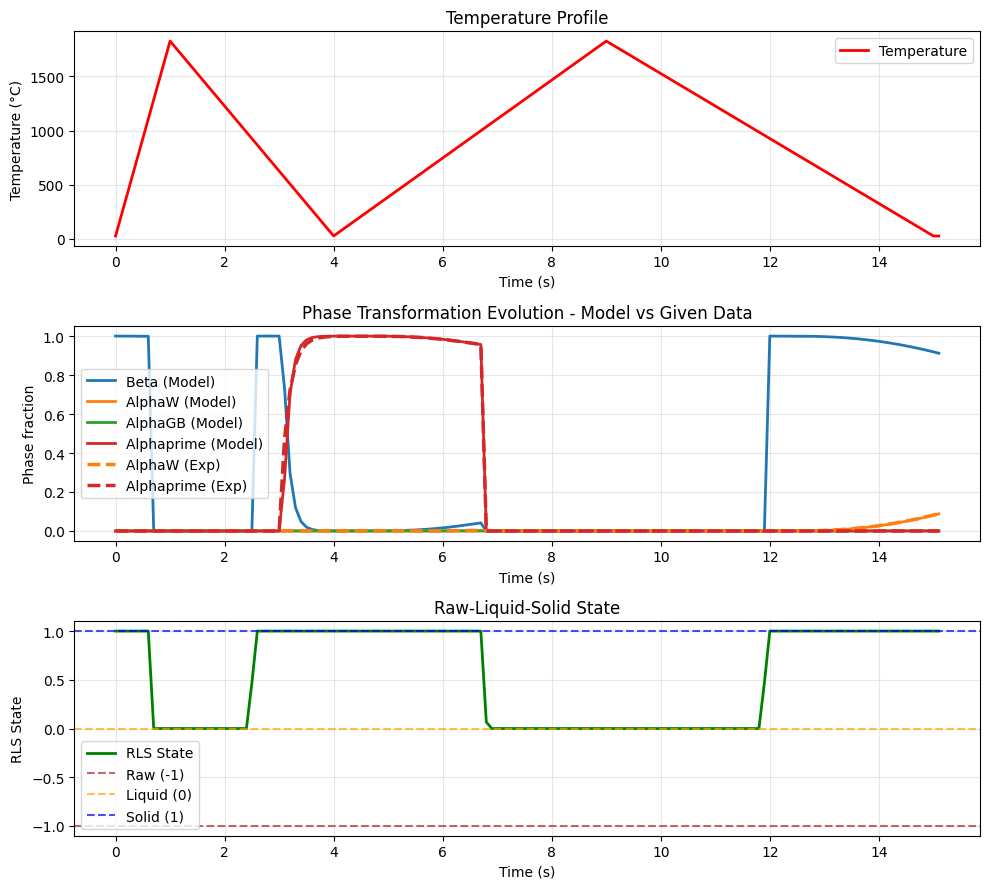


=== PHASE EVOLUTION SUMMARY ===
Beta: 1.000 → 0.912 (Δ-0.088)
AlphaW: 0.000 → 0.088 (Δ+0.088)


In [3]:
#Start
model = pyJMAK.jmak()

# Load the input file
model.loadInputFiles(TEMP_FILE, MATERIAL_INPUT_FILE)

# Main function computes the evolution of phase fractions over time
model.run_phase_trans_sim() 

# Indicate if the results are to be compared with the experimental/literature results
model.setExperimentalComparison(COMPARE_WITH_EXPERIMENTAL, exp_data_files) 

# Plot evolutions of temperature, phase fractions and RSL-state over time
model.plot_results()
